# Exploratory Data Analysis - Superstore Dataset


## Q1: Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Rows: 51290, Columns: 27


In [108]:
df = pd.read_csv('superstore.csv')

In [7]:
df.head(2)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4


### Q1 i. Count and Handle Missing values

In [14]:

#count missing values
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Count': missing})
missing_df = missing_df[missing_df['Count'] > 0]
print("Missing Values")
print(missing_df)


Missing Values
               Count
Shipping.Cost      5
State              3


In [18]:
#Handle missing values
df['Shipping.Cost'] = df['Shipping.Cost'].fillna(df['Shipping.Cost'].median())
df['State'] = df['State'].fillna('Unknown')

print(df.isnull().sum().sum(), "missing values remain")

0 missing values remain


### Q1 ii. Duplicate Values

In [20]:
#Find the number of duplicate rows and handle them by removing them
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")


Number of duplicate rows found: 0
No duplicates found.


### Q1 iii. Delect Unknown Columns

In [24]:
# Drop the 8th column ji lu shu
df = df.drop(df.columns[7], axis=1)
df.head(0)


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Priority,Product.ID,Product.Name,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum


Only one column is Unknow, the column H in the CSV file. It is named with symbols, the values are all 1 and not know what they represent. This will not aid in any calculations so can be removed.

### Q1 iv. Check shape, size and datatypes of the dataset features

In [30]:

print(f"Shape: {df.shape}")
print(f"Size (total elements): {df.size}")
print("\nData Types:")
print(df.dtypes)
#summary for the columns that have numerical values
df[['Discount','Profit','Quantity','Sales','Shipping.Cost']].describe().round(2)


Shape: (51290, 24)
Size (total elements): 1230960

Data Types:
Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object


,Discount,Profit,Quantity,Sales,Shipping.Cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,0.14,28.61,3.48,246.50,26.38
std,0.21,174.34,2.28,487.57,57.30
min,0.00,-6599.98,1.00,0.00,0.00
25%,0.00,0.00,2.00,31.00,2.61
50%,0.00,9.24,3.00,85.00,7.79
75%,0.20,36.81,5.00,251.00,24.45
max,0.85,8399.98,14.00,22638.00,933.57


## Q2 Perform Univariate Analysis across all *numerical features*

### Q2 i. WHich features seem useless? Why?

The features that seem useless or that don't add any value to the analysis are Row.ID and Year. 
The Row.ID column is used for indexing and has no value in the business analysis of the superstore. This indexing will not add any value when we calculate the sales or profit so this column can be safely removed. 


### Q2 ii. Which features are uniformly distributed or normally distributed?

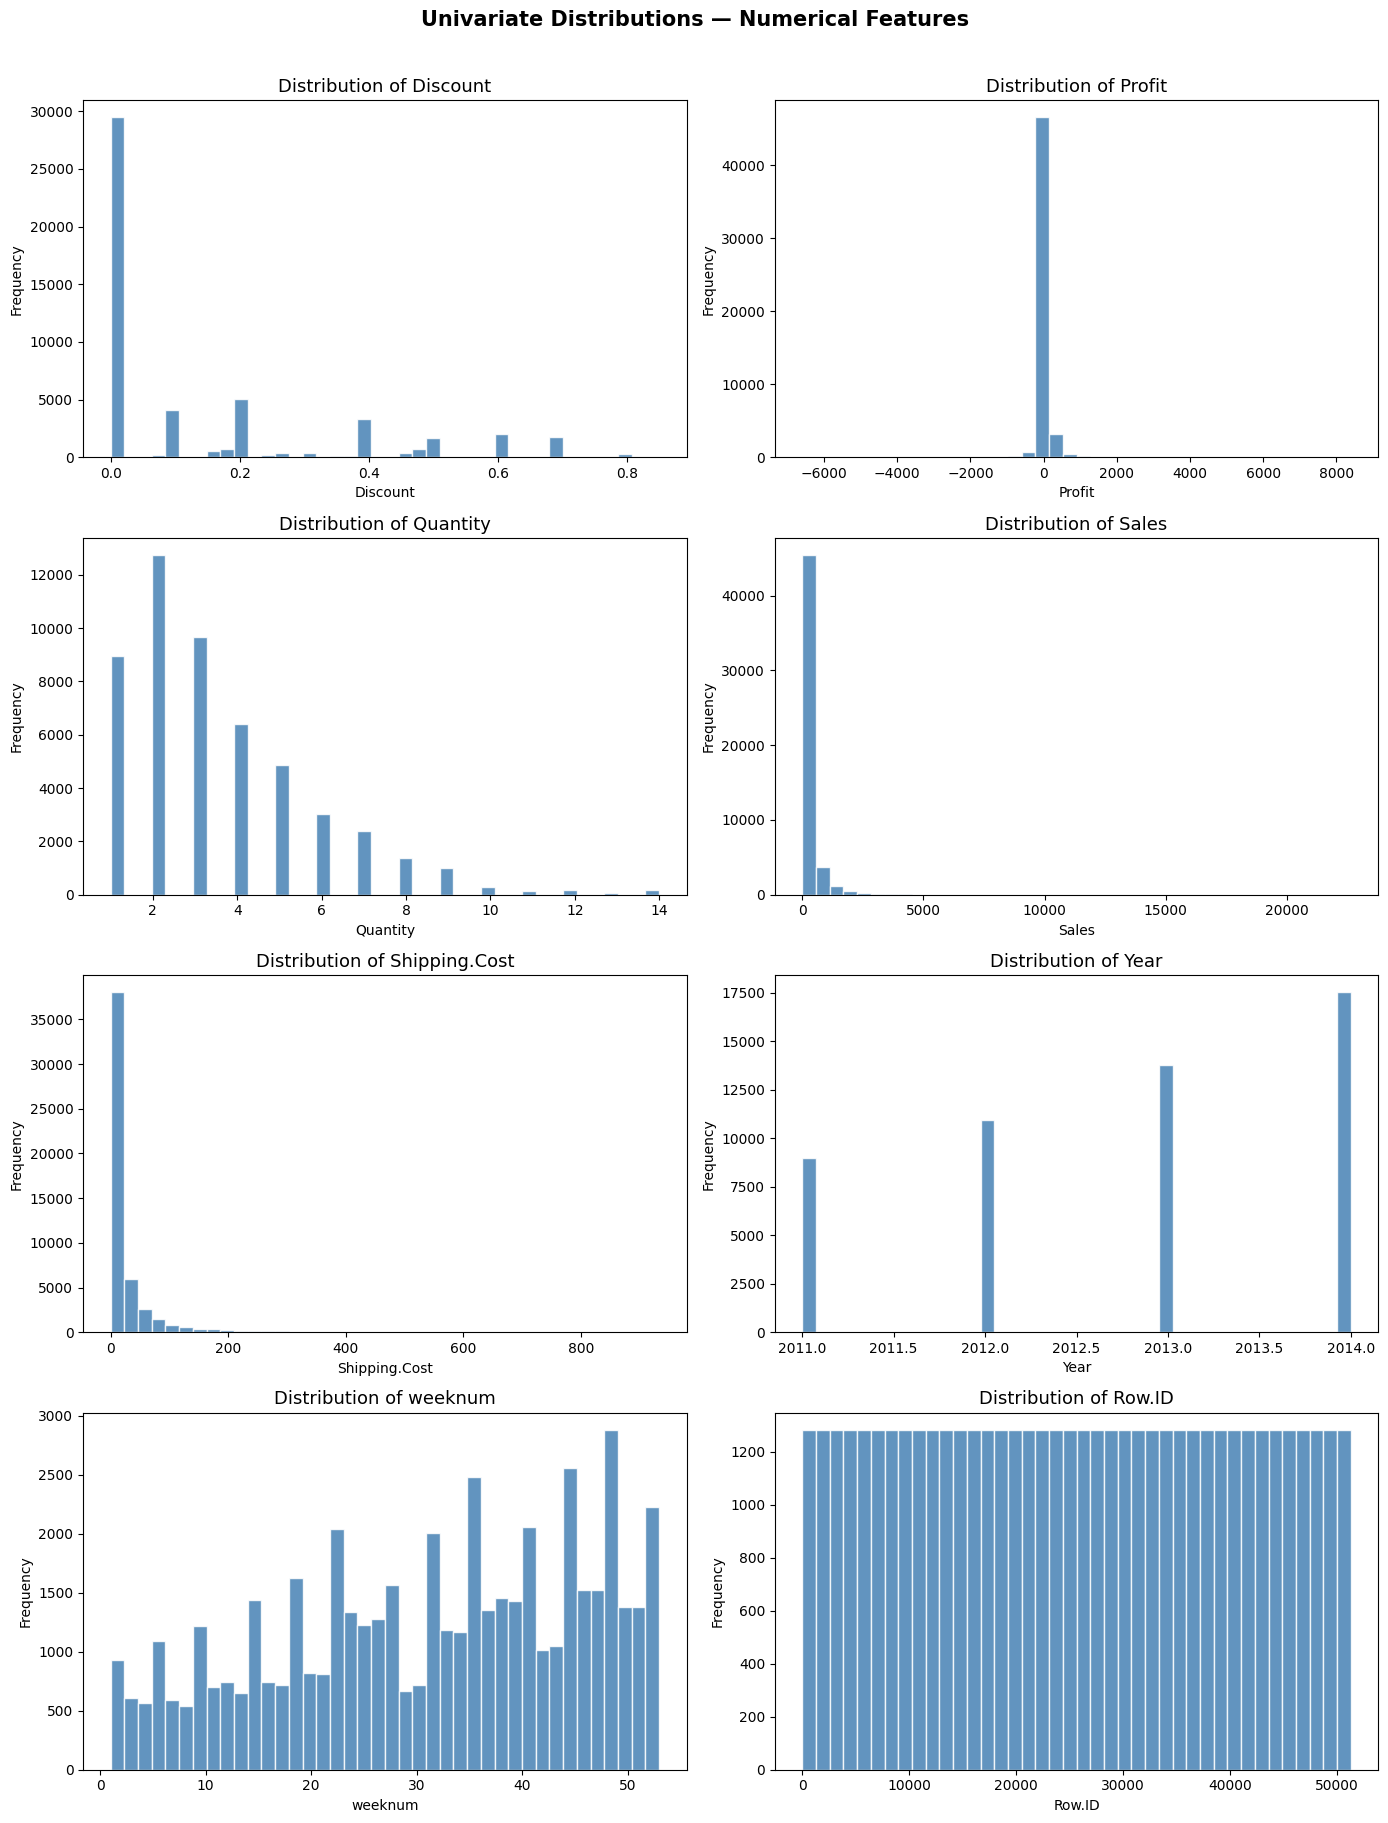

In [53]:

num_cols = ['Discount', 'Profit', 'Quantity', 'Sales', 'Shipping.Cost', 'Year', 'weeknum', 'Row.ID']
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Univariate Distributions — Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q2_univariate_numerical.png', dpi=120, bbox_inches='tight')
plt.show()



No feature has normal distribution, the only feature that comes close to normal distribution is *Quantity*

Uniform Distribution - Features *Weeknum* and *Row.ID* seem to have uniform distribution. Now *Row.ID* is not a useful feature giving any information

### Q2 iii. Which features are right-skewed/left-skewed? What does this signify? 


In [62]:

# Calculate skewness and convert it to a DataFrame
skew_df = df[num_cols].skew().reset_index()
skew_df.columns = ["Feature", "Skewness"]

value = [skew_df["Skewness"] > 0, skew_df["Skewness"] < 0]
type = ["Right", "Left"]
skew_df["Skew Type"] = np.select(value, type, default="Symmetrical")

print(skew_df)


         Feature      Skewness Skew Type
0       Discount  1.387775e+00     Right
1         Profit  4.157189e+00     Right
2       Quantity  1.360368e+00     Right
3          Sales  8.137981e+00     Right
4  Shipping.Cost  5.863256e+00     Right
5           Year -3.445153e-01      Left
6        weeknum -3.424505e-01      Left
7         Row.ID  6.006947e-18     Right


Most of features are right skewed. Mean > Median of these features.
For left skewed features like year and weeknum Mean < Median.

### Q2 iv. Which features have a high number of outliers, and discuss the impact. 


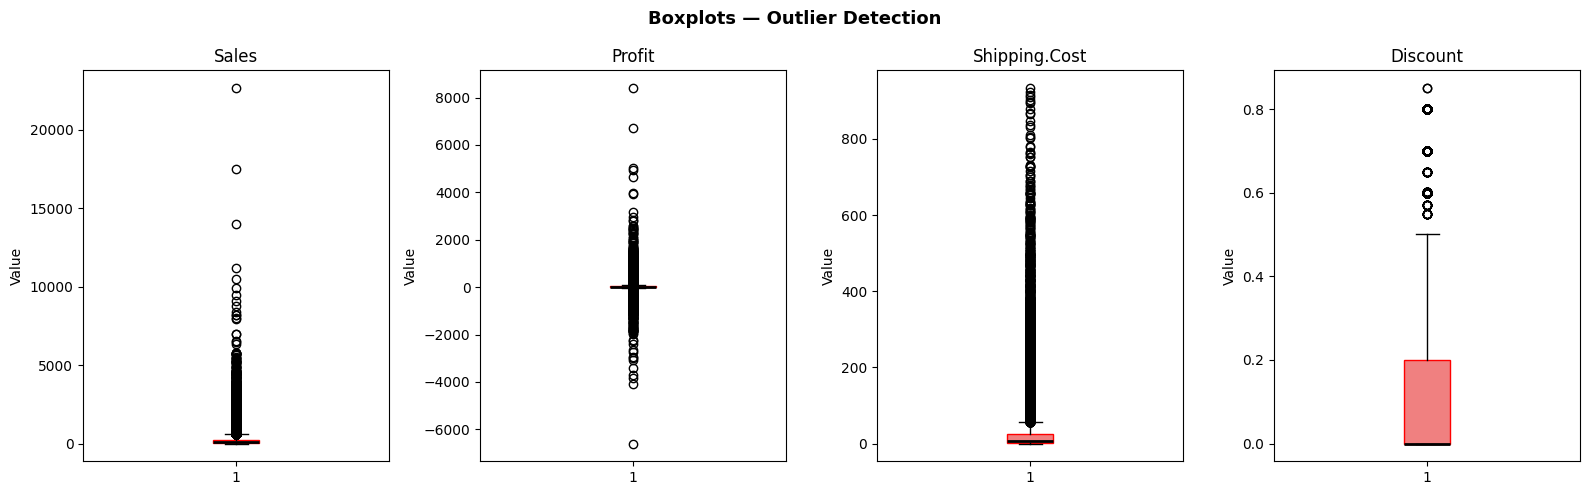

Sales: 5655 outliers (11.0%)
Profit: 9755 outliers (19.0%)
Shipping.Cost: 5909 outliers (11.5%)
Discount: 4172 outliers (8.1%)


In [63]:

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, ['Sales','Profit','Shipping.Cost','Discount']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='lightcoral', color='red'),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

# Count IQR outliers
for col in ['Sales','Profit','Shipping.Cost','Discount']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")


*Sales* has the high number outliers. SOme order reach upto $22,000.
*Profit* has the highest number of outlieers.The loss going upto -$6,000. The outliers are also on the positive side, this shows the orders are possibly taken at discounts.

These putliers represent the real business event and are hence impotant to be included for any prediction to be accurate.


## Q3 : Perform Univariate Analysis across all *categorical* features.

### Q3 i. Which features seem inaccurate and are not useful as categorical “insights” directly? 


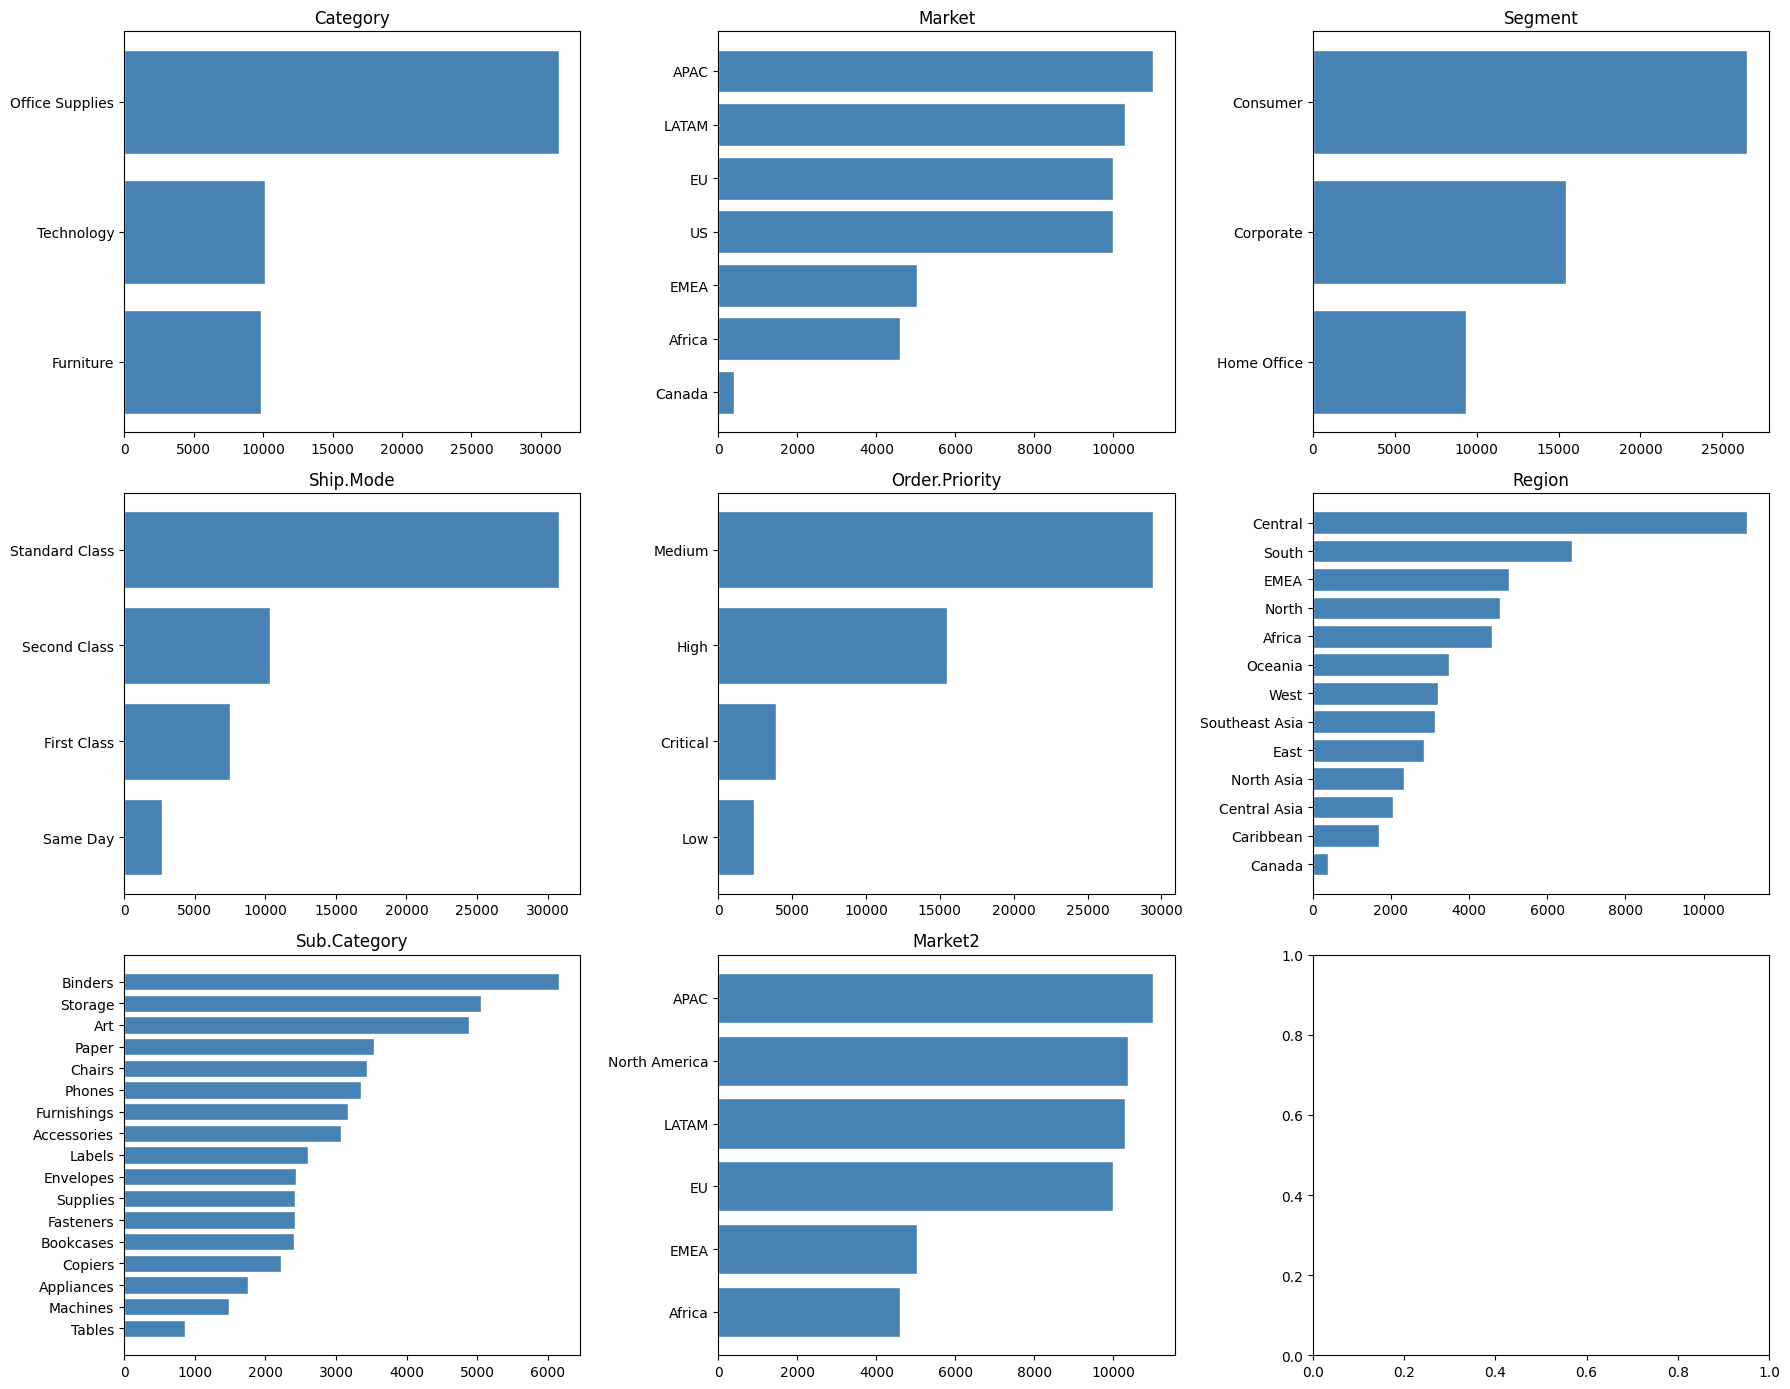

In [75]:

cat_cols = ['Category','Market','Segment','Ship.Mode','Order.Priority',
            'Region','Sub.Category','Market2','Country','City','State',
            'Customer.Name','Customer.ID','Product.Name','Product.ID',
            'Order.ID']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
plot_cats = ['Category','Market','Segment','Ship.Mode','Order.Priority','Region','Sub.Category','Market2']

for i, col in enumerate(plot_cats):
    val_counts = df[col].value_counts()
    axes[i].barh(val_counts.index.tolist(), val_counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12)
    axes[i].invert_yaxis()

plt.tight_layout()
plt.savefig('q3_categorical.png', dpi=120, bbox_inches='tight')
plt.show()


There are several features which don't give any insights.
1. *Order.ID, Product.ID, Customer.ID,ROw.ID* - These are all unique identifiers. Cannot be used for analysis. 
2. *Order.Date, Ship.Date* - Can be useful if converted to datetime.
3. *Market2* - It is similar to the column Market, just usdifferet name. Example- Use in amrket is North america in Market 2.

### Q3 ii. What’s the issue with treating Customer? Name as a categorical feature for modeling?

In [65]:

print(f"Unique Customer Names: {df['Customer.Name'].nunique()}")
print(f"Total rows: {len(df)}")
print(f"Average orders per customer: {len(df)/df['Customer.Name'].nunique():.1f}")


Unique Customer Names: 795
Total rows: 51290
Average orders per customer: 64.5


This feature has thousands of Customer Names and if this will be used as a categorical feature then there would be thousands of categories, pattern recognition can become difficult fot the model and when new customers are added to the list this becomes a problem for the prediction models and reduced the generalisability of the model


### Q3 iii. Is the Category distribution balanced or skewed? Give a 1-line reason. 

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64


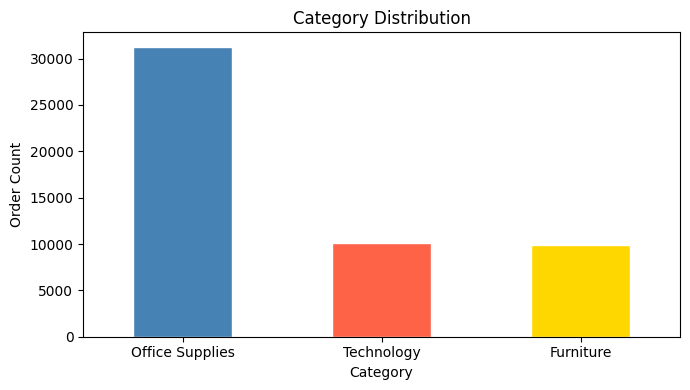

In [ ]:

cat_dist = df['Category'].value_counts()
print(cat_dist)
cat_dist.plot(kind='bar', color=['steelblue','tomato','gold'], edgecolor='white', figsize=(7,4))
plt.title('Category Distribution')
plt.ylabel('Order Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('q3_category.png', dpi=120, bbox_inches='tight')
plt.show()



The Category distribution is Skewed. Office supplies has much greater orders as compared to furniture or technology. 

### Q3 iv. In Country, does one country dominate strongly? What does that imply about geographic bias? 

Country
United States     9994
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64


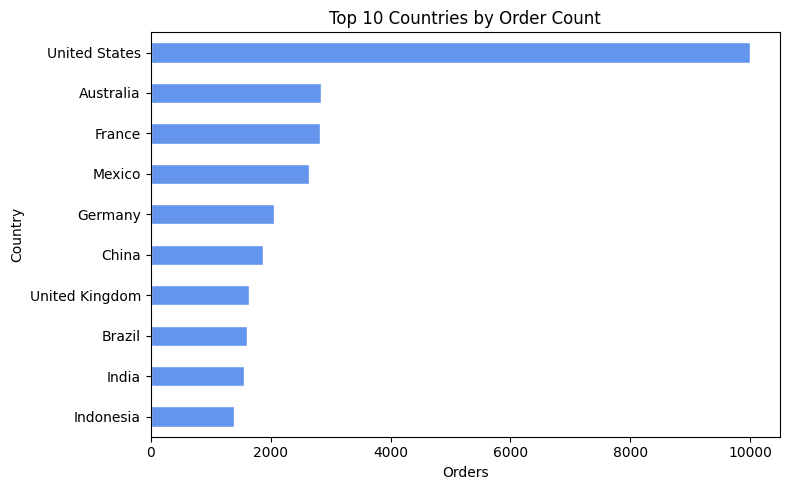

In [70]:

top_countries = df['Country'].value_counts().head(10)
print(top_countries)
top_countries.plot(kind='barh', color='cornflowerblue', edgecolor='white', figsize=(8,5))
plt.title('Top 10 Countries by Order Count')
plt.xlabel('Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q3_country.png', dpi=120, bbox_inches='tight')
plt.show()


Yes, USA dominates the orders with approx 10,000 orders. This is significantly greater than the next country which is autralia ~ 3000 order. The inghts will be heavily biased towards the US customer preferences and patterns. Although other countries are included int he study but the data from USA exceeds other countries by a huge margin.


### Q3 v. Is the City dataset concentrated in a few cities or spread out?

Total unique cities: 3636
City
New York City    915
Los Angeles      747
Philadelphia     537
San Francisco    510
Santo Domingo    443
Manila           432
Seattle          428
Houston          377
Tegucigalpa      362
Jakarta          337
Managua          336
Lagos            333
Istanbul         314
Chicago          314
Mexico City      300
Name: count, dtype: int64


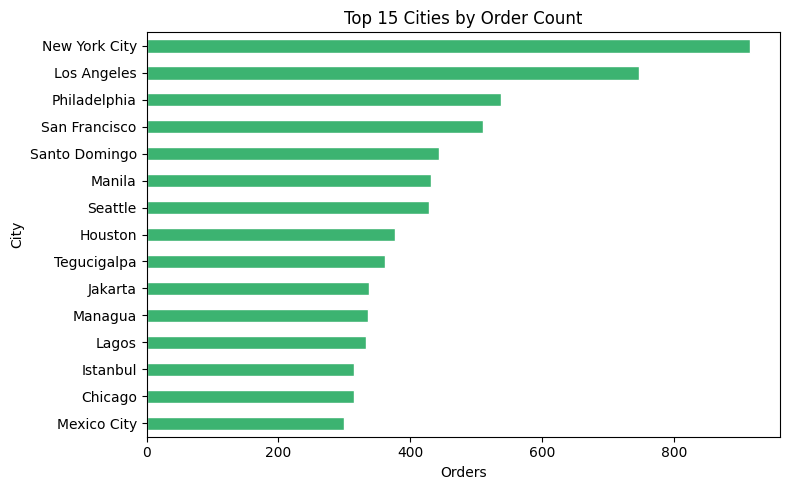

In [76]:

print(f"Total unique cities: {df['City'].nunique()}")
top_cities = df['City'].value_counts().head(15)
print(top_cities)
top_cities.plot(kind='barh', color='mediumseagreen', edgecolor='white', figsize=(8,5))
plt.title('Top 15 Cities by Order Count')
plt.xlabel('Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('q3_city.png', dpi=120, bbox_inches='tight')
plt.show()


The number of uniques cities in the datafrome is 3,636. 
The city dataset is spread across many cities and not just concentratred to the top cities.

## Q4: Perform Bivariant Analysis for *numerical-to-numerical* features

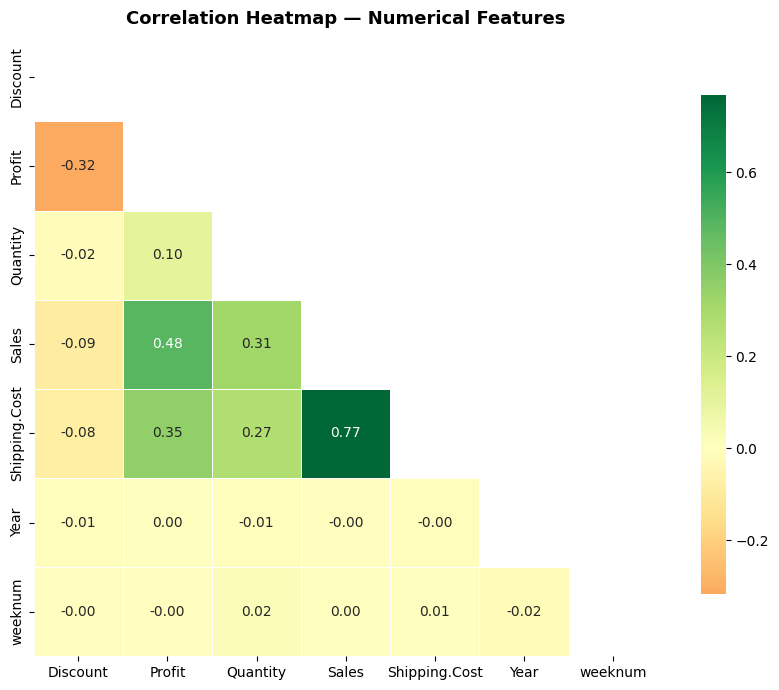

               Discount  Profit  Quantity  Sales  Shipping.Cost   Year  \
Discount          1.000  -0.316    -0.020 -0.087         -0.079 -0.006   
Profit           -0.316   1.000     0.104  0.485          0.354  0.003   
Quantity         -0.020   0.104     1.000  0.314          0.273 -0.005   
Sales            -0.087   0.485     0.314  1.000          0.768 -0.003   
Shipping.Cost    -0.079   0.354     0.273  0.768          1.000 -0.003   
Year             -0.006   0.003    -0.005 -0.003         -0.003  1.000   
weeknum          -0.000  -0.000     0.021  0.002          0.005 -0.020   

               weeknum  
Discount        -0.000  
Profit          -0.000  
Quantity         0.021  
Sales            0.002  
Shipping.Cost    0.005  
Year            -0.020  
weeknum          1.000  


In [77]:

num_features = ['Discount','Profit','Quantity','Sales','Shipping.Cost','Year','weeknum']
corr = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print(corr.round(3))


### Q4 i. Which two features are most strongly correlated?

*Sales* and *Shipping.Cost* are the most strong;y correlated pair

### Q4 ii.  Also name features that are negatively correlated.

The most significant negativelt correlated features are: 

1. Discount and Profit (r =-0.32)
2. Discount and Sales (r =- 0.09)
3. Dicount and Shipping.Cost(r = -0.08)



### Q4 iv.  Look for Time Effects Clues. Mention any information you find about the time relationship with any feature. 

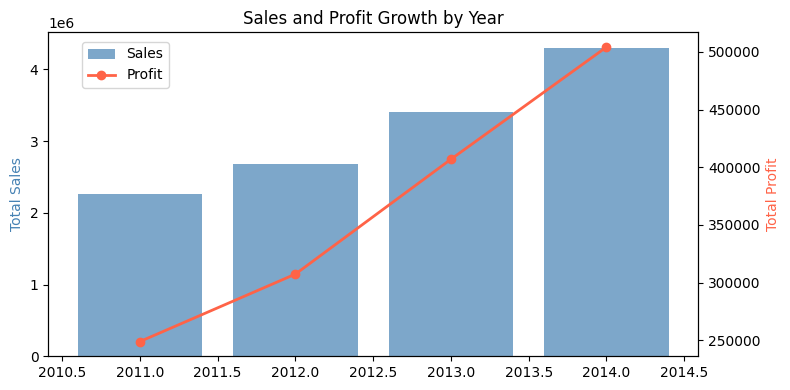

   Year    Sales        Profit
0  2011  2259511  248940.81154
1  2012  2677493  307415.27910
2  2013  3405860  406935.23018
3  2014  4300041  504165.97046


In [80]:

yearly = df.groupby('Year')[['Sales','Profit']].sum().reset_index()
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(yearly['Year'], yearly['Sales'], color='steelblue', alpha=0.7, label='Sales')
ax2.plot(yearly['Year'], yearly['Profit'], color='tomato', marker='o', linewidth=2, label='Profit')
ax1.set_ylabel('Total Sales', color='steelblue')
ax2.set_ylabel('Total Profit', color='tomato')
ax1.set_title('Sales and Profit Growth by Year', fontsize=12)
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.savefig('q4_time_effects.png', dpi=120, bbox_inches='tight')
plt.show()

print(yearly)


Both Sale and Profit show a consistent growth or uoward trend each year. Sales and profit doubled in 4 years

## Q5:  Perform Bi-variant Analysis for categorical to numerical features.:

### Q5. i. Profit by Category: Which category has the highest median profit? 

### Which has the lowest? 

### Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?

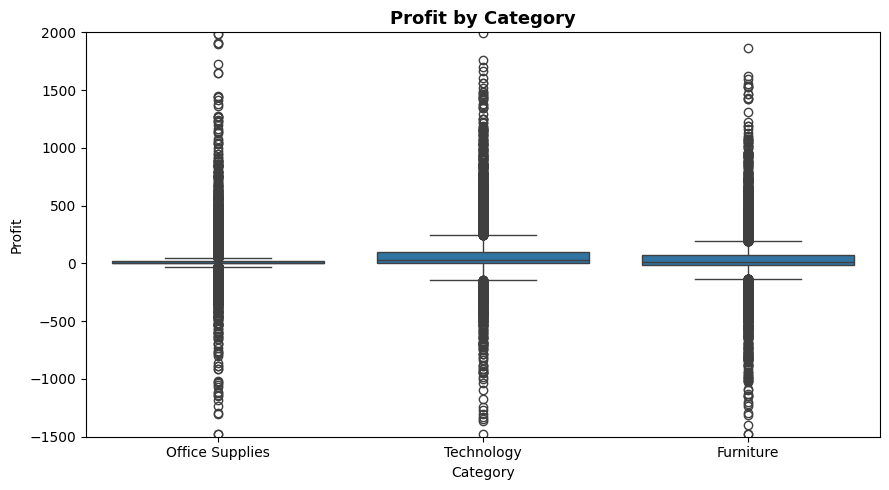

                   count   mean     std      min    25%    50%    75%      max
Category                                                                      
Furniture         9876.0  28.88  205.76 -2750.28 -12.18  15.50  69.36  2316.51
Office Supplies  31273.0  16.58  109.75 -3701.89   0.45   6.55  20.58  4946.37
Technology       10141.0  65.45  271.22 -6599.98   0.50  29.94  98.85  8399.98


In [85]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Profit by Category', fontsize=13, fontweight='bold')
plt.ylim(-1500, 2000)
plt.tight_layout()
plt.savefig('q5_profit_category.png', dpi=120, bbox_inches='tight')
plt.show()

print(df.groupby('Category')['Profit'].describe().round(2))


- Highest median profit - Technology
- Lowest Median profit - Office Supplies
- Widest spread (Largest IQR) - Technology

### Q5 . ii. Sales by Category: Which category has the highest median sales? Does it also have the highest median profit? 

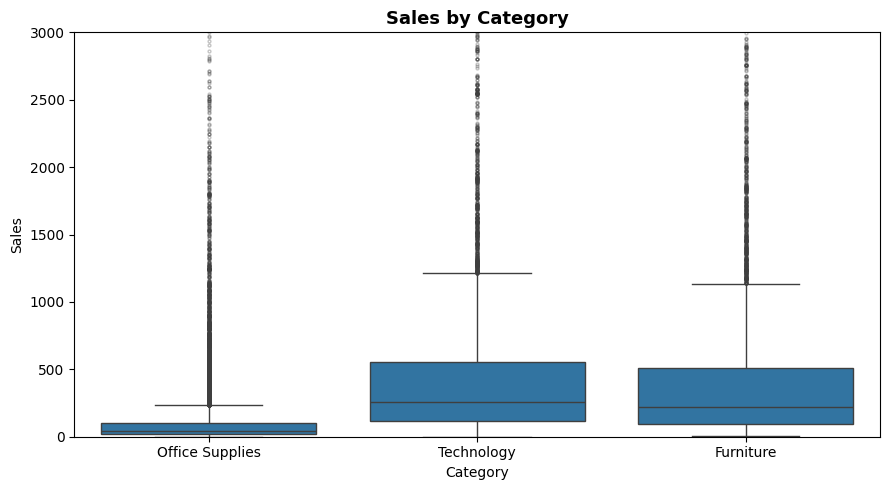

Category
Furniture          220.0
Office Supplies     46.0
Technology         260.0
Name: Sales, dtype: float64
Category
Furniture          15.5022
Office Supplies     6.5538
Technology         29.9400
Name: Profit, dtype: float64


In [87]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Category', y='Sales',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
plt.title('Sales by Category', fontsize=13, fontweight='bold')
plt.ylim(0, 3000)
plt.tight_layout()
plt.savefig('q5_sales_category.png', dpi=120, bbox_inches='tight')
plt.show()

print(df.groupby('Category')['Sales'].median())
print(df.groupby('Category')['Profit'].median())


- Highest median sales - Technology
- Highest Median Profit - Technology

- LOwest median sales - Office Supplies

### Q5 iii. Profit by Segment: 
### Which segment has the highest median profit? Which segment has the most negative/low profit outliers? 

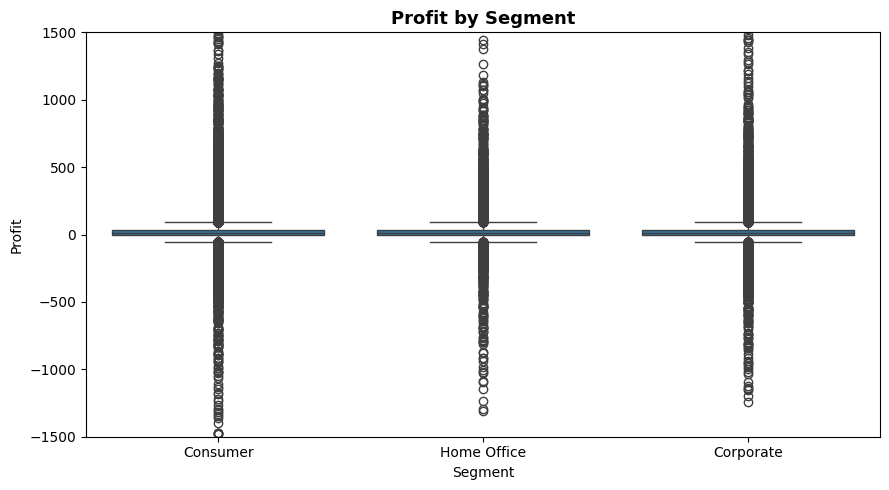

               count   mean     std      min  25%   50%    75%      max
Segment                                                                
Consumer     26518.0  28.25  174.01 -6599.98  0.0  9.18  36.65  6719.98
Corporate    15429.0  28.60  177.16 -4088.38  0.0  9.32  36.94  8399.98
Home Office   9343.0  29.65  170.58 -3399.98  0.0  9.32  37.08  3919.99


In [100]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Segment', y='Profit')
plt.title('Profit by Segment', fontsize=13, fontweight='bold')
plt.ylim(-1500, 1500)
plt.tight_layout()
plt.savefig('q5_profit_segment.png', dpi=120, bbox_inches='tight')
plt.show()

print(df.groupby('Segment')['Profit'].describe().round(2))


- Highest Median profit - Home office and Corporte.
All three show similar median.


### Q5. iv.  
### Sales by Segment: Which segment has the highest median sales? Is the profit  pattern consistent with sales? 

C:\Users\jghad\AppData\Local\Temp\ipykernel_3256\3510259543.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segment', y='Sales', palette='viridis',


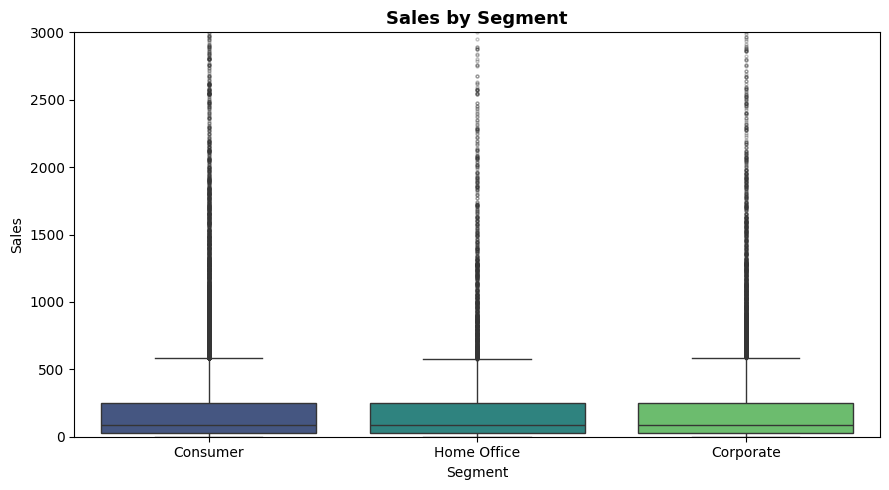

Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64


In [102]:

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Segment', y='Sales', palette='viridis',
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
plt.title('Sales by Segment', fontsize=13, fontweight='bold')
plt.ylim(0, 3000)
plt.tight_layout()
plt.savefig('q5_sales_segment.png', dpi=120, bbox_inches='tight')
plt.show()

print(df.groupby('Segment')['Sales'].median())


The profit is not consistent with the Sales as all three segemnts have similar medians.

## Q6 Perform Bivariate Analysis for Market features against Region, Category, and Country: 

### Q6 i. Is  the Market is not randomly spread across all Regions?

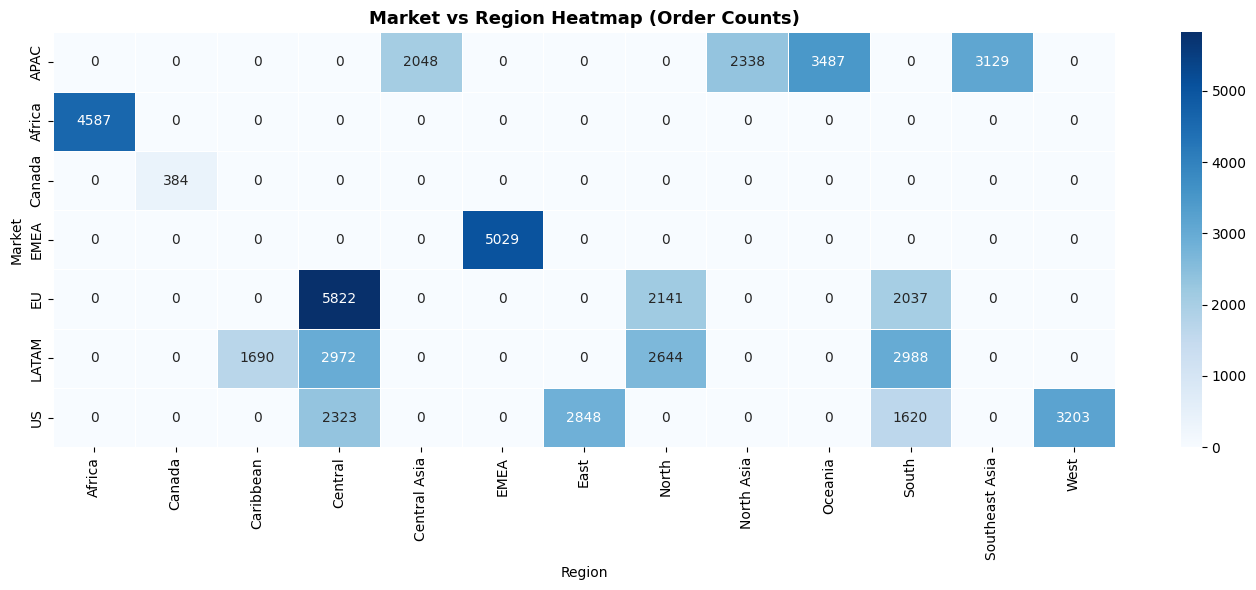

In [103]:

cross = pd.crosstab(df['Market'], df['Region'])
plt.figure(figsize=(14, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Market vs Region Heatmap (Order Counts)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q6_market_region.png', dpi=120, bbox_inches='tight')
plt.show()


The Market is not Randomly spread across all the Regions
Each Market has relateion to specific regions.

Example - 
1. US Market - only US regions
2. EU Market - Only European regions

### Q6 ii . hich country has negligible office supply orders?

In [104]:

cat_country = df.groupby(['Country','Category']).size().unstack(fill_value=0)

low_os = cat_country['Office Supplies'].sort_values().head(10)
print("Countries with fewest Office Supplies orders:")
print(low_os)


Countries with fewest Office Supplies orders:
Country
Burundi              0
South Sudan          0
Bahrain              1
Armenia              1
Swaziland            1
Eritrea              1
Equatorial Guinea    2
Guadeloupe           2
Slovenia             2
Lesotho              2
Name: Office Supplies, dtype: int64


### Q6 iii. What are the most useful insights? 

Profit by Market:
         mean  median        sum
Market                          
APAC    39.63   10.89  436000.05
Africa  19.37    7.56   88871.63
Canada  46.40   12.34   17817.39
EMEA     8.73    5.04   43897.97
EU      37.28   14.22  372829.74
LATAM   21.53    8.00  221643.49
US      28.66    8.67  286397.02


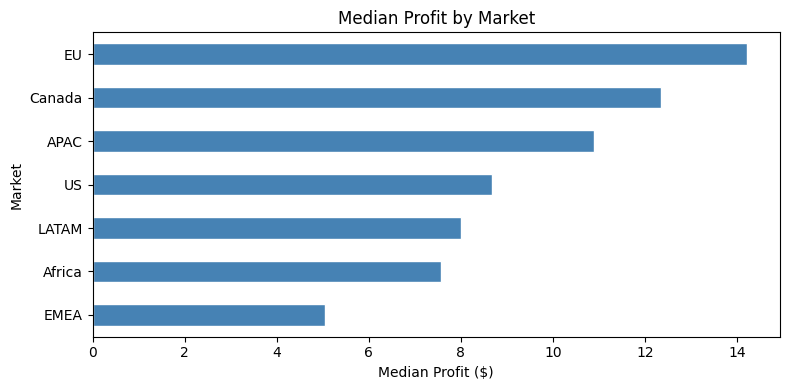

In [106]:

# Profit
market_profit = df.groupby('Market')['Profit'].agg(['mean','median','sum']).round(2)
print("Profit by Market:")
print(market_profit)

market_profit['median'].sort_values().plot(kind='barh', color='steelblue', edgecolor='white', figsize=(8,4))
plt.title('Median Profit by Market', fontsize=12)
plt.xlabel('Median Profit ($)')
plt.tight_layout()
plt.savefig('q6_market_profit.png', dpi=120, bbox_inches='tight')
plt.show()




In [107]:
cat_mix = df.groupby(['Market','Category']).size().unstack(fill_value=0)
cat_mix_pct = cat_mix.div(cat_mix.sum(axis=1), axis=0).round(3) * 100
print("\nCategory mix (%) by Market:")
print(cat_mix_pct)


Category mix (%) by Market:
Category  Furniture  Office Supplies  Technology
Market                                          
APAC           22.1             56.1        21.8
Africa         13.8             66.4        19.9
Canada         10.9             72.1        16.9
EMEA           15.3             65.6        19.1
EU             15.0             65.9        19.1
LATAM          23.1             56.9        19.9
US             21.2             60.3        18.5


From studyign the Market and regions, cateogory and cointry. These are the main insights-

1. APAC and EU have the highest profit markets by calculating the total profit
2. EMEA and AFRICA have the lowest median profits
3. US Market is the most well represented market. This is very good for all analysis regarding the US market.


